,precision,recall,f1-score,support
Hello,1.0,1.00,1.00,8.0
IloveYou,1.0,1.00,1.00,9.0
No,1.0,0.91,0.95,11.0
Please,1.0,1.00,1.00,7.0
Thanks,1.0,1.00,1.00,8.0
Yes,1.0,1.00,1.00,9.0
micro avg,1.0,0.98,0.99,52.0
macro avg,1.0,0.98,0.99,52.0
weighted avg,1.0,0.98,0.99,52.0


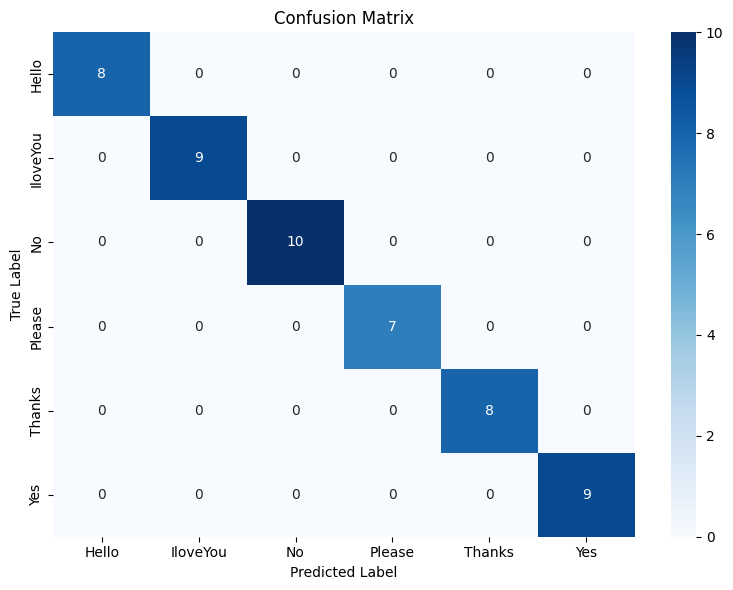

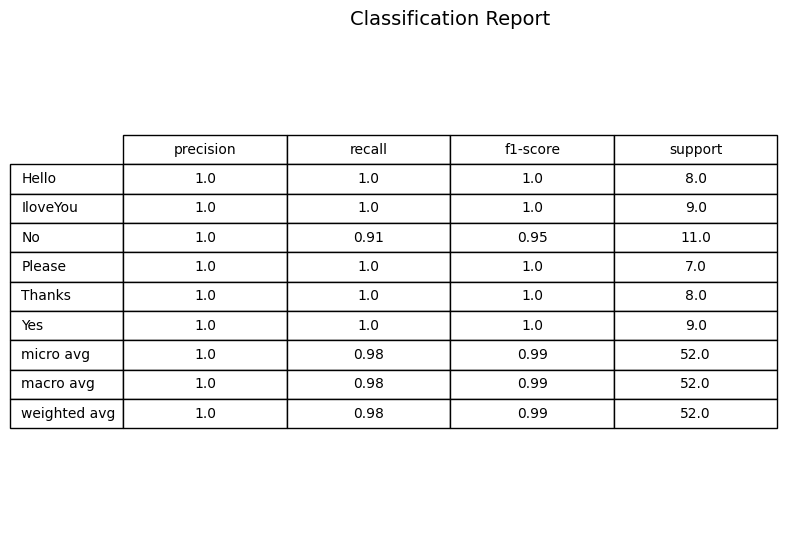

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from math import ceil
from ultralytics import YOLO
from sklearn.metrics import classification_report, confusion_matrix
from IPython.display import display

# ===== CẤU HÌNH =====
class_names = ['Hello', 'IloveYou', 'No', 'Please', 'Thanks', 'Yes']
test_dir = './Data/test/images'
model_path = 'best.pt'

# ===== LOAD MODEL =====
model = YOLO(model_path)

# ===== DỰ ĐOÁN =====
y_true = []
y_pred = []

for fname in os.listdir(test_dir):
    if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
        continue

    # Gán nhãn từ tên file
    true_label = next((c for c in class_names if fname.lower().startswith(c.lower())), None)
    if true_label is None:
        continue

    img_path = os.path.join(test_dir, fname)
    img = cv2.imread(img_path)
    if img is None:
        continue

    # Dự đoán
    results = model.predict(source=img, conf=0.25, verbose=False)
    pred_label = (
        results[0].names[int(results[0].boxes.cls[0])]
        if results[0].boxes else "No Detection"
    )

    y_true.append(true_label)
    y_pred.append(pred_label)

# ===== REPORT BẢNG DỄ ĐỌC =====
report = classification_report(
    y_true,
    y_pred,
    labels=class_names,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

df_report = pd.DataFrame(report).transpose()
display(df_report.round(2))  # Hiển thị đẹp trong notebook

# ===== CONFUSION MATRIX =====
cm = confusion_matrix(y_true, y_pred, labels=class_names)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('./output/confusion_matrix.png')
plt.show()

# ===== VẼ BẢNG REPORT BẰNG MATPLOTLIB (tuỳ chọn) =====
def plot_classification_table(report_df, save_path=None):
    fig, ax = plt.subplots(figsize=(8, len(report_df) * 0.5 + 1))
    ax.axis('off')
    table = ax.table(
        cellText=report_df.round(2).values,
        colLabels=report_df.columns,
        rowLabels=report_df.index,
        cellLoc='center',
        loc='center'
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.1, 1.5)
    plt.title("Classification Report", fontsize=14)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()

plot_classification_table(df_report, save_path="./output/classification_report.png")
